<a href="https://colab.research.google.com/github/DariaGolovacheva/-diploma_project/blob/main/%D0%97%D0%B0%D0%B4%D0%B0%D0%BD%D0%B8%D0%B51.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Задание 1.**
# РАСПОЗНАВАНИЕ И ОБРАБОТКА ВРЕМЕННЫХ РЯДОВ

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import pytz
from statsmodels.tsa.seasonal import seasonal_decompose
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

In [2]:
%pip install rpy2 -q
%load_ext rpy2.ipython

In [3]:
%%R
install.packages(c("lubridate", "zoo", "imputeTS"), repos="http://cran.rstudio.com/", quiet=TRUE)

also installing the dependencies ‘xts’, ‘TTR’, ‘quantmod’, ‘gridtext’, ‘tseries’, ‘ggtext’, ‘forecast’



In [4]:
from google.colab import files

uploaded_r = files.upload()
uploaded = files.upload()

Saving missing.R to missing.R
Saving smoothing.R to smoothing.R
Saving timeZones.R to timeZones.R


Saving day.csv to day.csv


## Получение временных рядов из данных

In [5]:
bike = pd.read_csv('day.csv')
bike.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [6]:
bike.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [7]:
bike['dteday'] = pd.to_datetime(bike['dteday'])
bike = bike.set_index('dteday').sort_index()
bike[['cnt', 'casual', 'registered', 'temp']].describe()

,cnt,casual,registered,temp
count,731.000000,731.000000,731.000000,731.000000
mean,4504.348837,848.176471,3656.172367,0.495385
std,1937.211452,686.622488,1560.256377,0.183051
min,22.000000,2.000000,20.000000,0.059130
25%,3152.000000,315.500000,2497.000000,0.337083
50%,4548.000000,713.000000,3662.000000,0.498333
75%,5956.000000,1096.000000,4776.500000,0.655417
max,8714.000000,3410.000000,6946.000000,0.861667


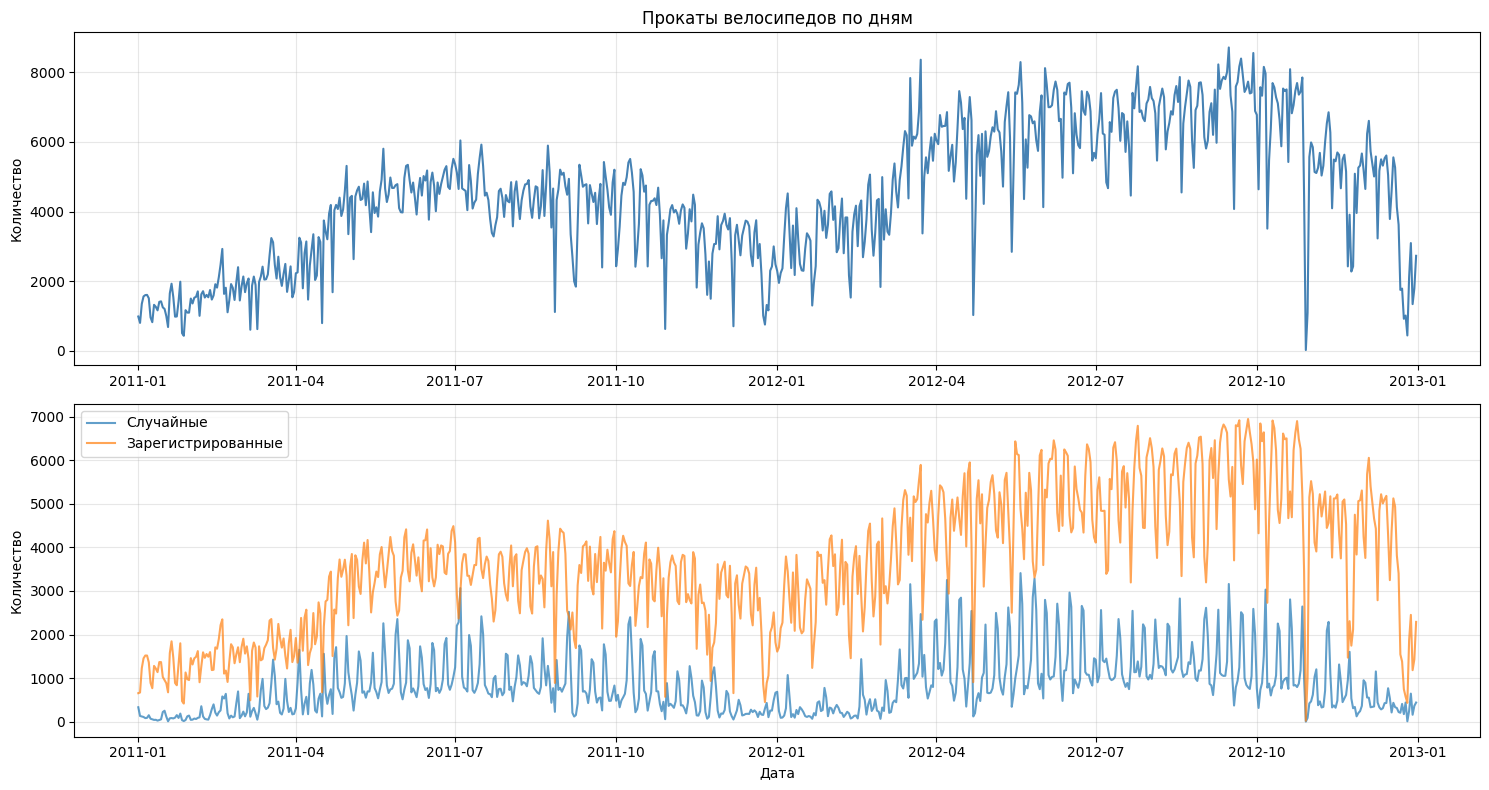

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(15, 8))

axes[0].plot(bike.index, bike['cnt'], linewidth=1.5, color='steelblue')
axes[0].set_title('Прокаты велосипедов по дням')
axes[0].set_ylabel('Количество')
axes[0].grid(True, alpha=0.3)

axes[1].plot(bike.index, bike['casual'], label='Случайные', linewidth=1.5, alpha=0.7)
axes[1].plot(bike.index, bike['registered'], label='Зарегистрированные', linewidth=1.5, alpha=0.7)
axes[1].set_ylabel('Количество')
axes[1].set_xlabel('Дата')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [9]:
bike_weekly = bike.resample('W').agg({'cnt': 'sum', 'casual': 'sum', 'registered': 'sum', 'temp': 'mean', 'hum': 'mean'})
bike_weekly.head(15)

,cnt,casual,registered,temp,hum
dteday,,,,,
2011-01-02,1786,462,1324,0.353823,0.750960
2011-01-09,9408,668,8740,0.189646,0.493089
2011-01-16,9025,674,8351,0.183360,0.537081
2011-01-23,8770,605,8165,0.182785,0.567549
2011-01-30,7699,622,7077,0.192842,0.689379
2011-02-06,10273,764,9509,0.221491,0.675611
2011-02-13,11192,1118,10074,0.214249,0.530907
2011-02-20,14692,2575,12117,0.377319,0.390153
2011-02-27,12113,1746,10367,0.284753,0.604758


In [10]:
bike_monthly = bike.resample('M').agg({'cnt': 'sum', 'temp': 'mean', 'hum': 'mean', 'windspeed': 'mean'})
bike_monthly.head(12)

,cnt,temp,hum,windspeed
dteday,,,,
2011-01-31,38189,0.197707,0.584366,0.195419
2011-02-28,48215,0.282540,0.560093,0.228568
2011-03-31,64045,0.331667,0.569414,0.232408
2011-04-30,94870,0.471188,0.668287,0.244216
2011-05-31,135821,0.577231,0.713360,0.181274
2011-06-30,143512,0.693083,0.593250,0.178195
2011-07-31,141341,0.758575,0.589664,0.171667
2011-08-31,136691,0.705362,0.626831,0.190721
2011-09-30,127418,0.612887,0.784054,0.152989


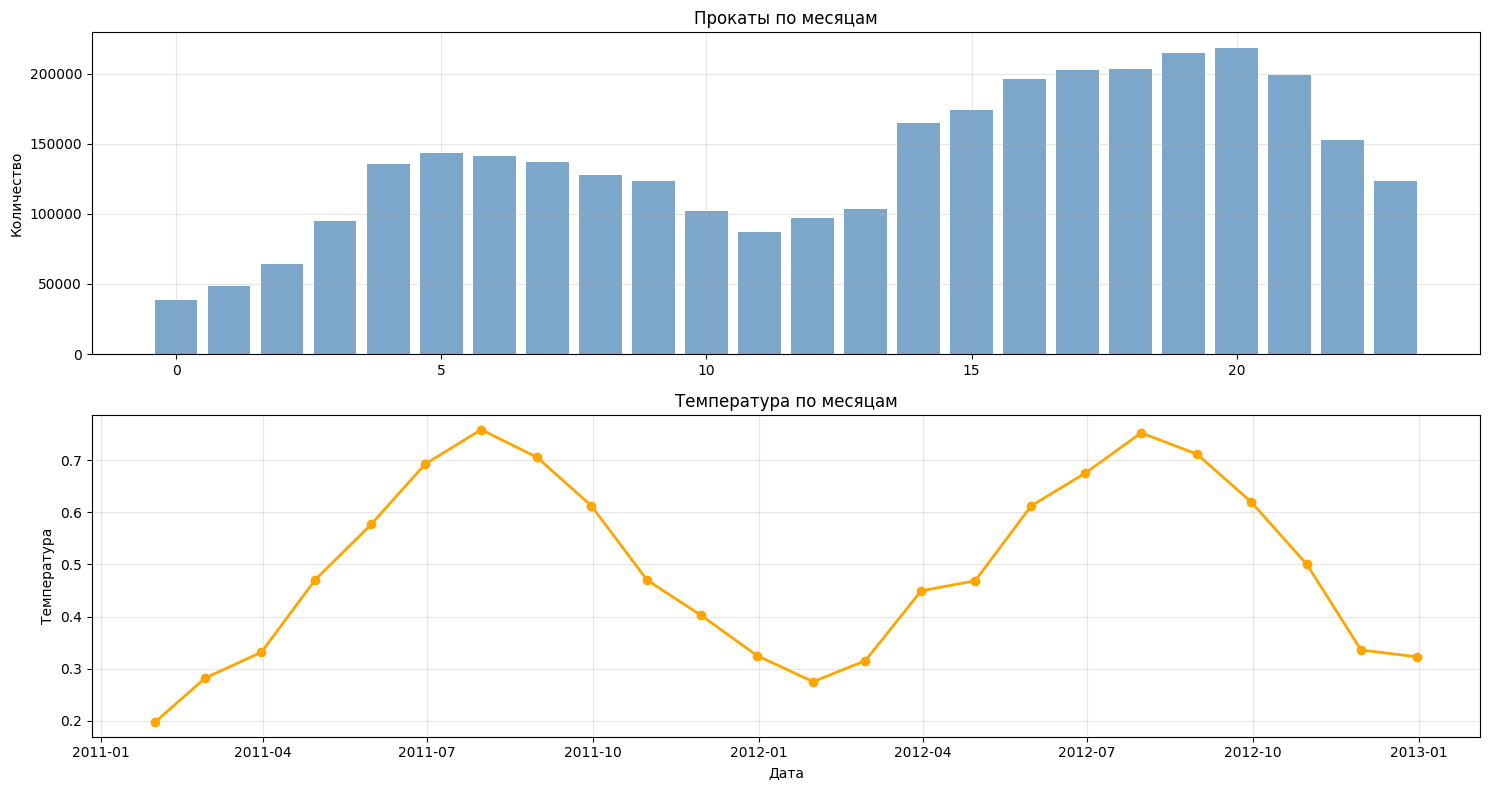

In [11]:
fig, axes = plt.subplots(2, 1, figsize=(15, 8))

axes[0].bar(range(len(bike_monthly)), bike_monthly['cnt'], color='steelblue', alpha=0.7)
axes[0].set_title('Прокаты по месяцам')
axes[0].set_ylabel('Количество')
axes[0].grid(True, alpha=0.3)

axes[1].plot(bike_monthly.index, bike_monthly['temp'], marker='o', linewidth=2, color='orange')
axes[1].set_title('Температура по месяцам')
axes[1].set_ylabel('Температура')
axes[1].set_xlabel('Дата')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Работа с часовыми поясами

In [12]:
import datetime
import pytz

utc_now = datetime.datetime.utcnow()
local_now = datetime.datetime.now()

print(f"UTC: {utc_now}")
print(f"Локальное: {local_now}")

moscow_tz = pytz.timezone('Europe/Moscow')
london_tz = pytz.timezone('Europe/London')
ny_tz = pytz.timezone('America/New_York')

dt_moscow = moscow_tz.localize(datetime.datetime(2024, 11, 5, 15, 0, 0))
print(f"Москва: {dt_moscow}")
print(f"Лондон: {dt_moscow.astimezone(london_tz)}")
print(f"Нью-Йорк: {dt_moscow.astimezone(ny_tz)}")

UTC: 2025-11-05 19:19:42.254521
Локальное: 2025-11-05 19:19:42.254577
Москва: 2024-11-05 15:00:00+03:00
Лондон: 2024-11-05 12:00:00+00:00
Нью-Йорк: 2024-11-05 07:00:00-05:00


In [13]:
%%R
source("timeZones.R")

UTC: 2025-11-05 19:19:42 
Москва: 2025-11-05 22:19:42 

Москва: 2024-11-05 15:00:00 
Лондон: 2024-11-05 12:00:00 
Нью-Йорк: 2024-11-05 07:00:00 



Attaching package: ‘lubridate’

The following objects are masked from ‘package:base’:

    date, intersect, setdiff, union



## Обработка недостающих данных

In [14]:
url = "https://fred.stlouisfed.org/graph/fredgraph.csv?id=UNRATE"
unemp = pd.read_csv(url)

date_col = unemp.columns[0]
value_col = unemp.columns[1]

unemp[date_col] = pd.to_datetime(unemp[date_col])
unemp = unemp.set_index(date_col).sort_index()

unemp.head()

,UNRATE
observation_date,
1948-01-01,3.4
1948-02-01,3.8
1948-03-01,4.0
1948-04-01,3.9
1948-05-01,3.5


In [15]:
unemp_original = unemp.copy()

np.random.seed(42)
rand_idx = np.random.choice(unemp.index, size=int(0.1 * len(unemp)), replace=False)
unemp_missing = unemp.copy()
unemp_missing.loc[rand_idx, value_col] = np.nan

print(f"Пропусков: {unemp_missing[value_col].isna().sum()}")

Пропусков: 93


In [16]:
df_imputed = unemp_missing.copy()

df_imputed['impute_ff'] = df_imputed[value_col].fillna(method='ffill')
df_imputed['impute_linear'] = df_imputed[value_col].interpolate(method='linear')
df_imputed['impute_spline'] = df_imputed[value_col].interpolate(method='spline', order=2)

df_imputed.head(20)

,UNRATE,impute_ff,impute_linear,impute_spline
observation_date,,,,
1948-01-01,3.4,3.4,3.4,3.4
1948-02-01,3.8,3.8,3.8,3.8
1948-03-01,4.0,4.0,4.0,4.0
1948-04-01,3.9,3.9,3.9,3.9
1948-05-01,3.5,3.5,3.5,3.5
1948-06-01,3.6,3.6,3.6,3.6
1948-07-01,3.6,3.6,3.6,3.6
1948-08-01,3.9,3.9,3.9,3.9
1948-09-01,3.8,3.8,3.8,3.8


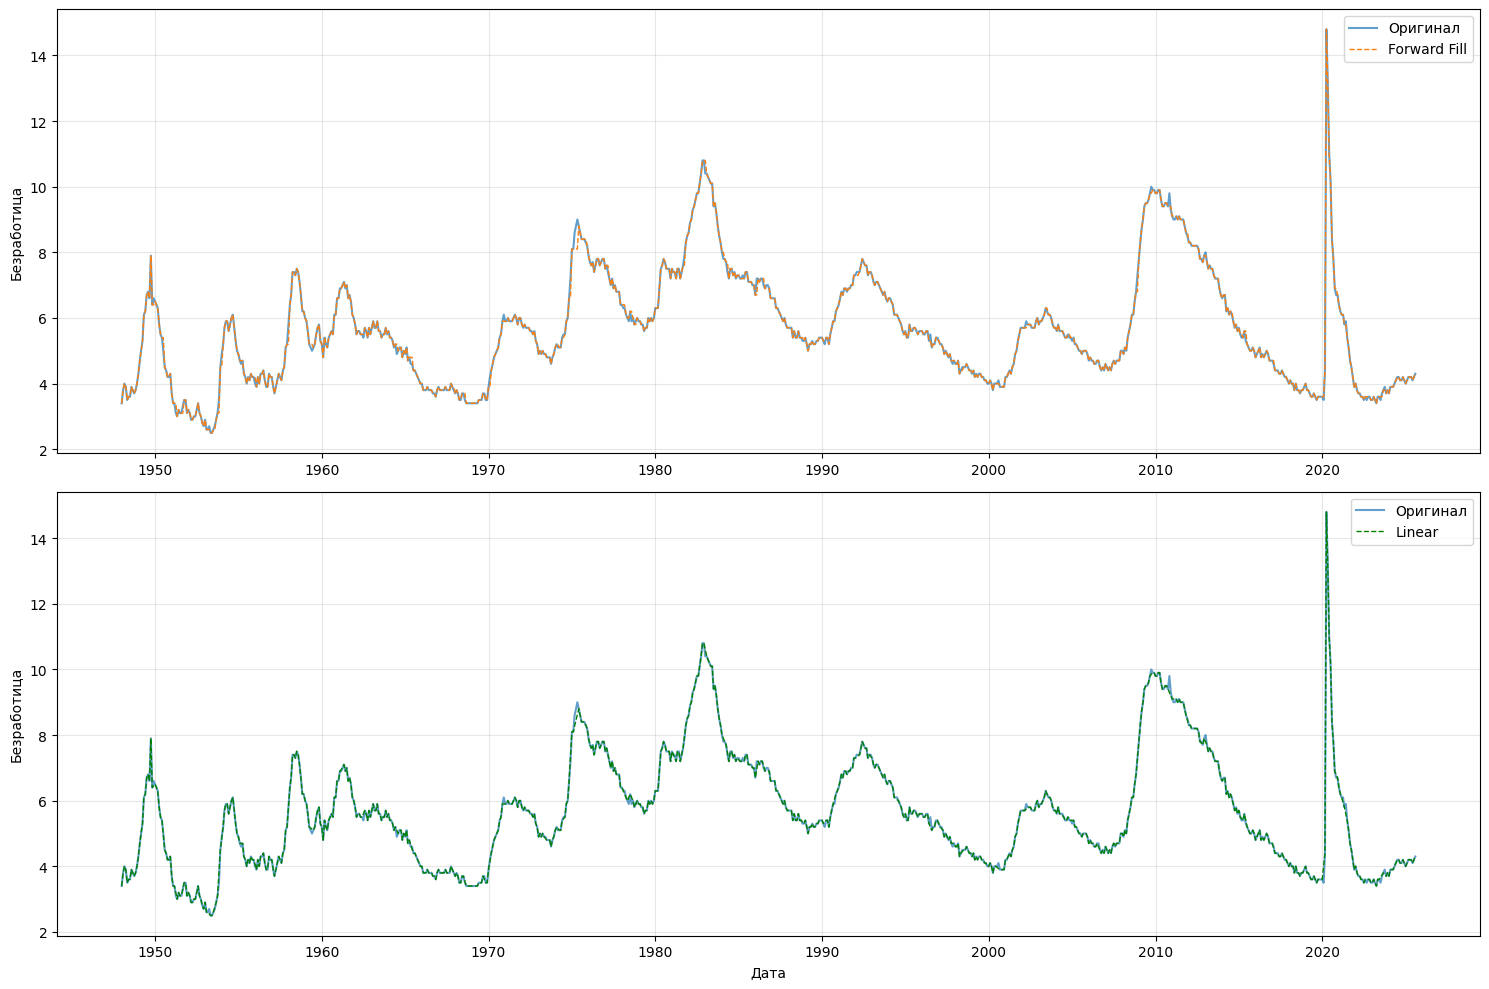

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(15, 10))

axes[0].plot(unemp_original.index, unemp_original[value_col], label='Оригинал', linewidth=1.5, alpha=0.7)
axes[0].plot(df_imputed.index, df_imputed['impute_ff'], label='Forward Fill', linestyle='--', linewidth=1)
axes[0].set_ylabel('Безработица')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(unemp_original.index, unemp_original[value_col], label='Оригинал', linewidth=1.5, alpha=0.7)
axes[1].plot(df_imputed.index, df_imputed['impute_linear'], label='Linear', linestyle='--', linewidth=1, color='green')
axes[1].set_ylabel('Безработица')
axes[1].set_xlabel('Дата')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [18]:
from sklearn.metrics import mean_squared_error

mask = unemp_missing[value_col].isna()
methods = {'Forward Fill': 'impute_ff', 'Linear': 'impute_linear', 'Spline': 'impute_spline'}

results = []
for name, col in methods.items():
    mse = mean_squared_error(unemp_original.loc[mask, value_col], df_imputed.loc[mask, col])
    results.append({'Метод': name, 'MSE': mse})

pd.DataFrame(results).sort_values('MSE')

,Метод,MSE
1,Linear,0.021788
0,Forward Fill,0.055914
2,Spline,1.003179


In [19]:
%%R
source("missing.R")

Пропусков: 10 

Forward Fill:
 [1] 7.741917 3.870604 5.726257 6.265725 5.808537 4.787751 8.023044 4.810682
 [9] 9.036847 4.874572 7.609739 9.573291 2.222279 2.222279 4.733357

Linear:
 [1] 7.741917 3.870604 5.726257 6.265725 5.808537 4.787751 8.023044 4.810682
 [9] 9.036847 4.874572 7.609739 9.573291 2.222279 3.477818 4.733357

Spline:
 [1] 7.741917 3.870604 5.726257 6.265725 5.808537 4.787751 8.023044 4.810682
 [9] 9.036847 4.874572 7.609739 9.573291 2.222279 1.190750 4.733357



Attaching package: ‘zoo’

The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric

Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 

Attaching package: ‘imputeTS’

The following object is masked from ‘package:zoo’:

    na.locf

In addition: Warning message:
In na.locf(ts_data) : na.locf will be replaced by na_locf.
    Functionality stays the same.
    The new function name better fits modern R code style guidelines.
    Please adjust your code accordingly.


## Сглаживание данных

In [20]:
bike_smooth = bike.copy()

bike_smooth['Smooth_0.1'] = bike_smooth['cnt'].ewm(alpha=0.1).mean()
bike_smooth['Smooth_0.5'] = bike_smooth['cnt'].ewm(alpha=0.5).mean()
bike_smooth['Smooth_0.9'] = bike_smooth['cnt'].ewm(alpha=0.9).mean()

bike_smooth[['cnt', 'Smooth_0.1', 'Smooth_0.5', 'Smooth_0.9']].head(15)

,cnt,Smooth_0.1,Smooth_0.5,Smooth_0.9
dteday,,,,
2011-01-01,985,985.000000,985.000000,985.000000
2011-01-02,801,888.157895,862.333333,817.727273
2011-01-03,1349,1058.210332,1140.428571,1296.351351
2011-01-04,1562,1204.703402,1365.266667,1535.459046
2011-01-05,1600,1301.232571,1486.419355,1593.546485
2011-01-06,1606,1366.276125,1547.158730,1604.754660
2011-01-07,1510,1393.825104,1528.433071,1519.475457
2011-01-08,959,1317.477418,1242.600000,1015.047541
2011-01-09,822,1236.593646,1031.888454,841.304754


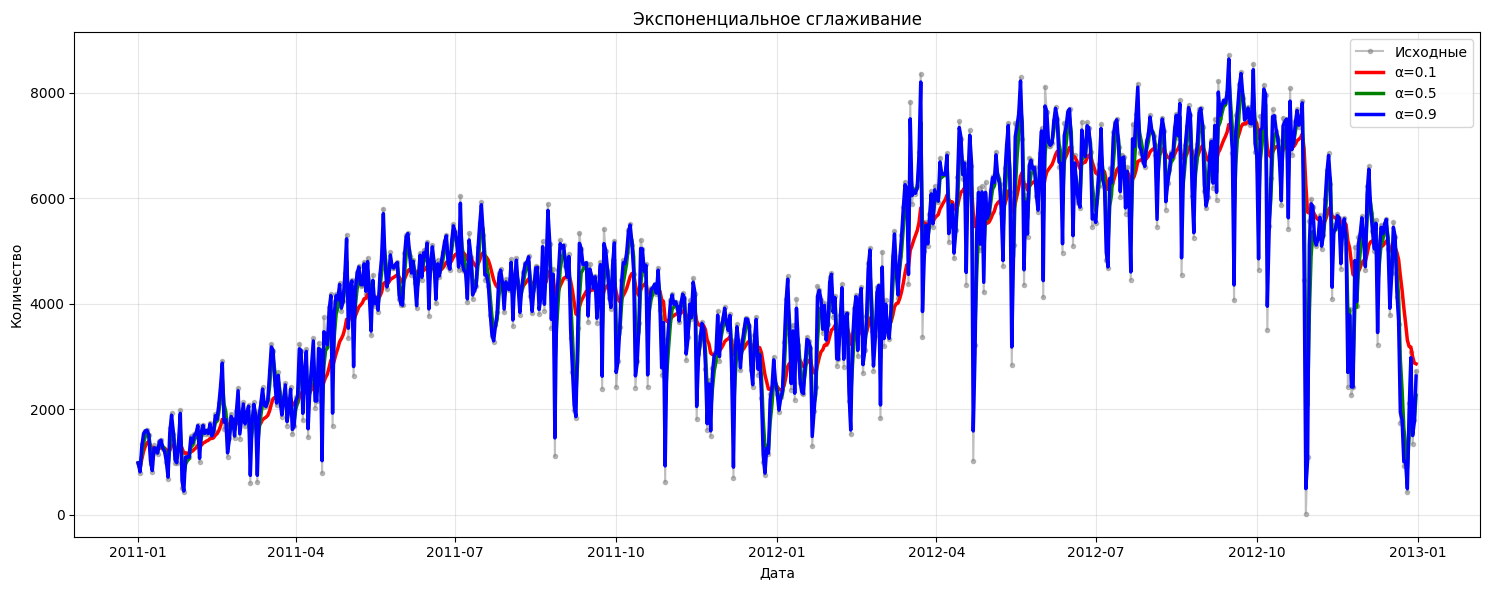

In [21]:
plt.figure(figsize=(15, 6))

plt.plot(bike_smooth.index, bike_smooth['cnt'], label='Исходные', linewidth=1.5, alpha=0.5, color='gray', marker='.')
plt.plot(bike_smooth.index, bike_smooth['Smooth_0.1'], label='α=0.1', linewidth=2.5, color='red')
plt.plot(bike_smooth.index, bike_smooth['Smooth_0.5'], label='α=0.5', linewidth=2.5, color='green')
plt.plot(bike_smooth.index, bike_smooth['Smooth_0.9'], label='α=0.9', linewidth=2.5, color='blue')

plt.title('Экспоненциальное сглаживание')
plt.xlabel('Дата')
plt.ylabel('Количество')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [22]:
%%R
source("smoothing.R")

α=0.1:
Time Series:
Start = 2 
End = 11 
Frequency = 1 
 [1]  89.79049  90.55108  94.91339  95.96307  97.12534 101.44293 102.92047
 [8] 100.89830 100.33477 100.40997

α=0.5:
Time Series:
Start = 2 
End = 11 
Frequency = 1 
 [1]  89.79049  93.59347 113.88382 109.64699 108.61637 124.45884 120.33858
 [8] 101.51868  98.39081  99.73879

α=0.9:
Time Series:
Start = 2 
End = 11 
Frequency = 1 
 [1]  89.79049  96.63585 130.42034 107.91118 107.61830 137.03300 118.29979
 [8]  86.25888  94.36254 100.41434


## Декомпозиция временных рядов

In [23]:
bike_ts = bike.resample('W').sum()['cnt']
bike_ts = bike_ts.asfreq('W')
bike_ts.head(10)

,cnt
dteday,
2011-01-02,1786
2011-01-09,9408
2011-01-16,9025
2011-01-23,8770
2011-01-30,7699
2011-02-06,10273
2011-02-13,11192
2011-02-20,14692
2011-02-27,12113


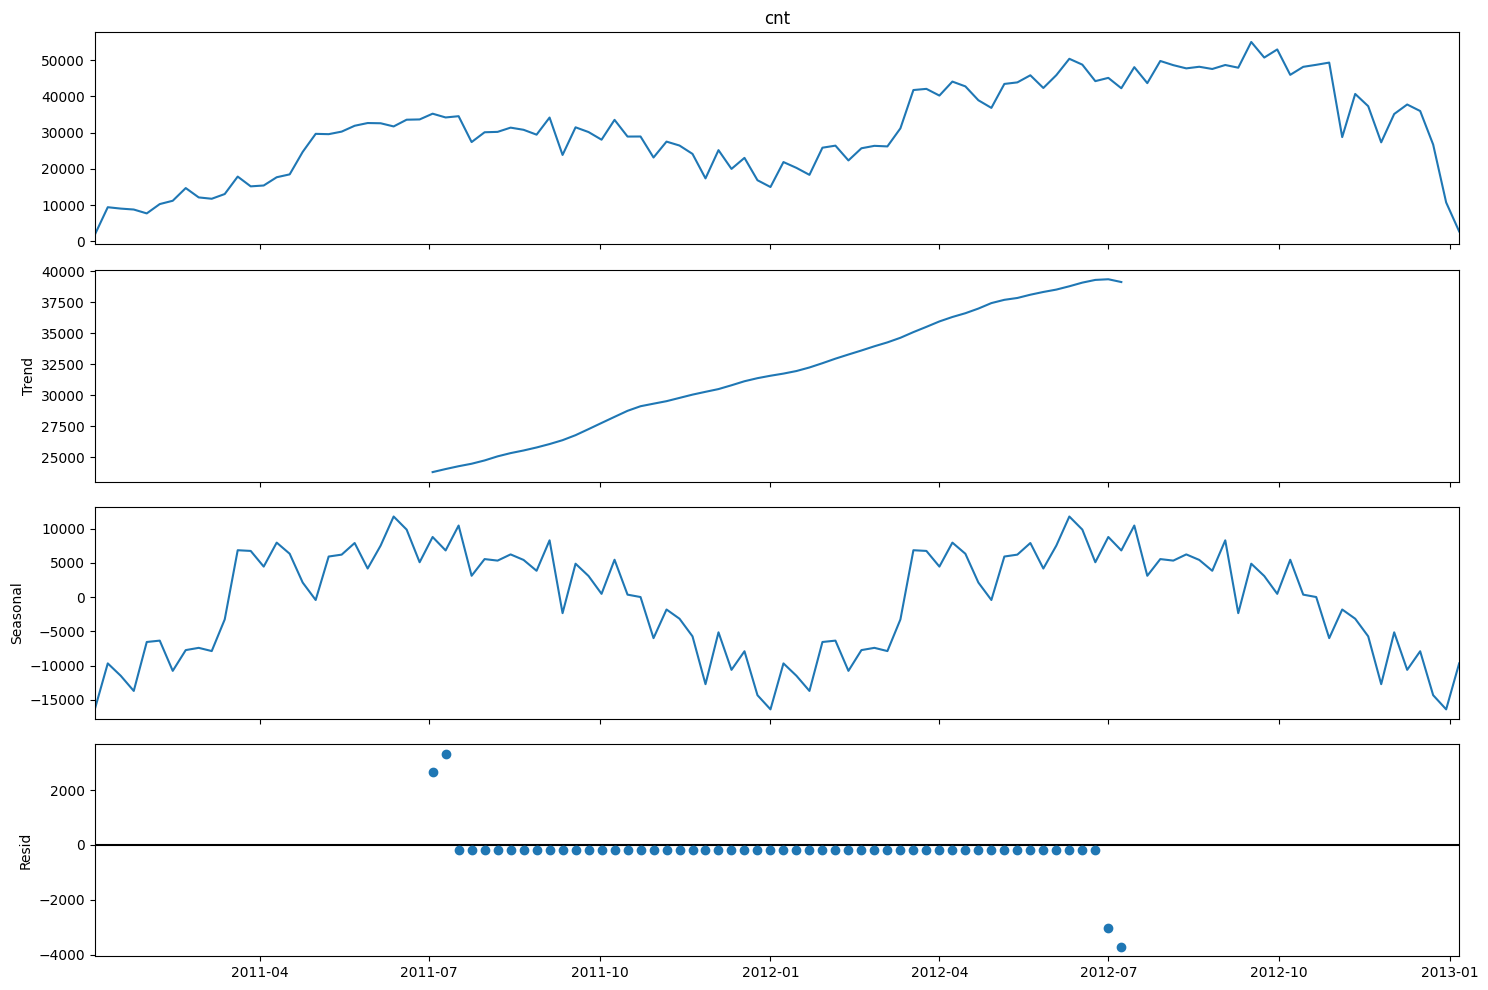

In [24]:
decomposition = seasonal_decompose(bike_ts, model='additive', period=52)

fig = decomposition.plot()
fig.set_size_inches(15, 10)
plt.tight_layout()
plt.show()

In [25]:
trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

print("Тренд:")
print(trend.head(15))
print("Сезонность:")
print(seasonal.head(15))
print("Остаток:")
print(residual.head(15))

Тренд:
dteday
2011-01-02   NaN
2011-01-09   NaN
2011-01-16   NaN
2011-01-23   NaN
2011-01-30   NaN
2011-02-06   NaN
2011-02-13   NaN
2011-02-20   NaN
2011-02-27   NaN
2011-03-06   NaN
2011-03-13   NaN
2011-03-20   NaN
2011-03-27   NaN
2011-04-03   NaN
2011-04-10   NaN
Freq: W-SUN, Name: trend, dtype: float64
Сезонность:
dteday
2011-01-02   -16393.363443
2011-01-09    -9676.998058
2011-01-16   -11489.680751
2011-01-23   -13700.228828
2011-01-30    -6549.853828
2011-02-06    -6351.180751
2011-02-13   -10768.594212
2011-02-20    -7734.228828
2011-02-27    -7405.892289
2011-03-06    -7876.699982
2011-03-13    -3254.767289
2011-03-20     6857.126942
2011-03-27     6754.857711
2011-04-03     4466.540403
2011-04-10     7968.501942
Freq: W-SUN, Name: seasonal, dtype: float64
Остаток:
dteday
2011-01-02   NaN
2011-01-09   NaN
2011-01-16   NaN
2011-01-23   NaN
2011-01-30   NaN
2011-02-06   NaN
2011-02-13   NaN
2011-02-20   NaN
2011-02-27   NaN
2011-03-06   NaN
2011-03-13   NaN
2011-03-20   NaN
20

## Выводы

Использованные данные:
1. Bike Sharing Dataset (UCI ML Repository)
2. UNRATE

Результаты:
- Преобразованы дневные данные во временные ряды
- Обнаружена сезонная зависимость
- Продемонстрированы методы восполнения пропусков
- Лучший метод по MSE: линейная интерполяция
- Применено экспоненциальное сглаживание
- Выполнена декомпозиция временного ряда